<a href="https://colab.research.google.com/github/gnaveenpaul123-cyber/Project-3/blob/main/project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/gnaveenpaul123-cyber/Project-3/refs/heads/main/dirty_cafe_sales%20(1).csv')

So every time we get a new data set we need to make sure that some analysis to be done before get into actual analysis. Those are shape, column name, info etc. By doing so we will get idea about what this dataset means.

In [5]:
df.shape
#10000 rows, 8 columns present in dataset

(10000, 8)

In [7]:
df.info()
#all the data types of the columns are obj.
#we need to check the data and should take a call to change that column into correct dtype
# Null also present inthe data set.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [8]:
df.describe()
# There are 367 unique in date but normal year should have 365 and leap year 366 days.
#So there are some differences or fault in date

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [10]:
df.columns
# Total 8 columns with mixed of upper and lower.
#so for my convenient i would like the names all in lower. So that it would be easy for me type quickly for that
df.columns = df.columns.str.lower()
#By doing so i have conerted names into str and applied string function lower.


There are a lot of null present in each column

transaction id	0

item	          333

quantity	      138

price per unit	179

total spent	    173

payment method	2579

location	      3265

transaction date 159

In [18]:
df.isna().sum()
#There are a lot of null present in each column

,0
transaction id,0
item,333
quantity,138
price per unit,179
total spent,173
payment method,2579
location,3265
transaction date,159


In [34]:
df['quantity'] = pd.to_numeric(df['quantity'], errors = 'coerce')
# i have type castedquantity from obj to int.
# if any data in that column not follows base 10 will be changed as null.

In [42]:
columns_to_change = ['price per unit', 'total spent']
for col in columns_to_change:
  df[col] = pd.to_numeric(df[col], errors = 'coerce')
  print(f"{col} columns converted from obj to float sucessfully")
#To type cast multi[le columns at a time

price per unit columns converted from obj to float sucessfully
total spent columns converted from obj to float sucessfully


In [41]:
df['transaction date'] = pd.to_datetime(df['transaction date'], errors = 'coerce')
#changed transaction date from obj to timedate

In [57]:
#checking the duplicates.
df.duplicated().sum()
#There are no duplicates in the data.

np.int64(0)

In [109]:
#i'm dropping nulls values in the price per unit, total spent.
df.dropna(subset = ['quantity','price per unit','total spent'], inplace = True)
print("dropped null values sucessfully")

dropped null values sucessfully


In [69]:
df['item'].unique()

array(['Coffee', 'Cake', 'Salad', 'Smoothie', 'UNKNOWN', 'Sandwich',
       'Cookie', 'ERROR', 'Juice', 'Tea'], dtype=object)

In [74]:
# filling nulls in item, location, payment method columns with unknown
df['item'].fillna('UNKNOWN', inplace = True)
df['location'].fillna('UNKNOWN', inplace = True)
df['payment method'].fillna('UNKNOWN', inplace = True)

In [107]:
#creating a new column for total price
df['total_price'] = df['quantity'] * df['price per unit']

In [112]:
#checking total price vs total spent.
df[df['total spent'] != df['total_price']]

,transaction id,item,quantity,price per unit,total spent,payment method,location,transaction date,total_price


In [124]:
df = df.dropna(subset=['transaction date'])

In [137]:
df = df.drop('month', axis =1)

In [138]:
df['month'] = df['transaction date'].dt.month
df['day_name'] = df['transaction date'].dt.day_name()
df['day'] = df['transaction date'].dt.day

In [142]:
(10000 - 8159) / 10000 * 100

18.41

In [146]:
#Total revenue
total_revenue = df['total_price'].sum()
print(f"the total revenue is: {total_revenue}")

the total revenue is: 72704.5


In [155]:
#Which location performs best?
df.groupby('location')['total spent'].sum().sort_values(ascending = False)
#unknown performs best

,total spent
location,
UNKNOWN,26216.0
In-store,22240.0
Takeaway,21615.0
ERROR,2633.5


In [179]:
# check which item generating high
top_products = df.groupby('item')['total_price'].sum().sort_values(ascending = False).head(5)
display(top_products)
#salad item generating more income

,total_price
item,
Salad,14195.0
Sandwich,10992.0
Smoothie,10888.0
Juice,8631.0
Cake,8577.0


/tmp/ipykernel_14939/1341739498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_products, palette = 'coolwarm')


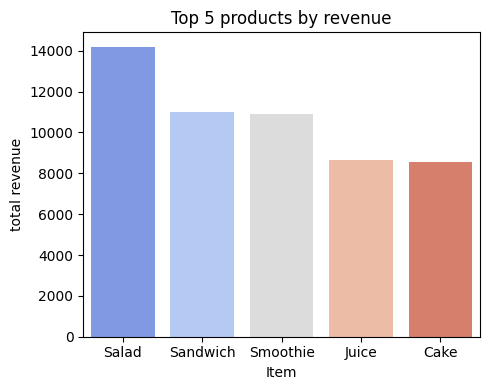

In [234]:
#Top 5 products by revenue (Bar chart)
plt.figure(figsize=(5,4))
sns.barplot(top_products, palette = 'coolwarm')
plt.title('Top 5 products by revenue')
plt.xlabel('Item')
plt.ylabel('total revenue')
plt.tight_layout()
plt.show()

###Why this chart?
 A bar chart is excellent for comparing discrete categories, in this case, the revenue generated by different products. It makes it easy to see which items are performing best at a glance.
###Insights:
This chart revealed that 'Salad' is the top-performing product, generating the most revenue, followed by 'Sandwich' and 'Smoothie'. This highlights the key items contributing significantly to sales.

In [184]:
#What is the busiest day of the week?
weekday_revenue = df.groupby('day_name')['transaction id'].count()
display(weekday_revenue)
#busiest day of the week is monday

,transaction id
day_name,
Friday,1167
Monday,1205
Saturday,1173
Sunday,1176
Thursday,1185
Tuesday,1118
Wednesday,1135


/tmp/ipykernel_14939/1740050310.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(weekday_revenue, palette = 'coolwarm')


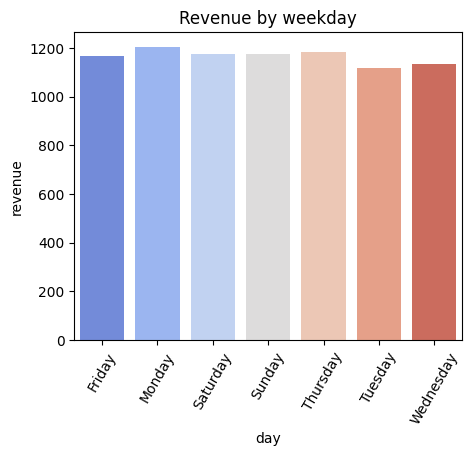

In [194]:
#Revenue by weekday (Bar chart)
plt.figure(figsize=(5,4))
sns.barplot(weekday_revenue, palette = 'coolwarm')
plt.title('Revenue by weekday')
plt.xlabel('day')
plt.ylabel('revenue')
plt.xticks(rotation = 60)
plt.show()

###Why this chart?
Similar to the product revenue, a bar chart is suitable for comparing revenue across different days of the week. It quickly shows which days are busier or generate more sales.
###Insights:
The bar chart indicated that 'Monday' is the busiest day of the week in terms of transaction count, followed closely by 'Saturday' and 'Sunday'. This can inform staffing and inventory decisions.

In [202]:
#sales monthly
sales_month = df.groupby('month')['total spent'].sum()
display(sales_month)

,total spent
month,
1,6055.5
2,5725.5
3,6089.5
4,6048.0
5,5923.5
6,6399.5
7,6063.0
8,6279.5
9,5865.0


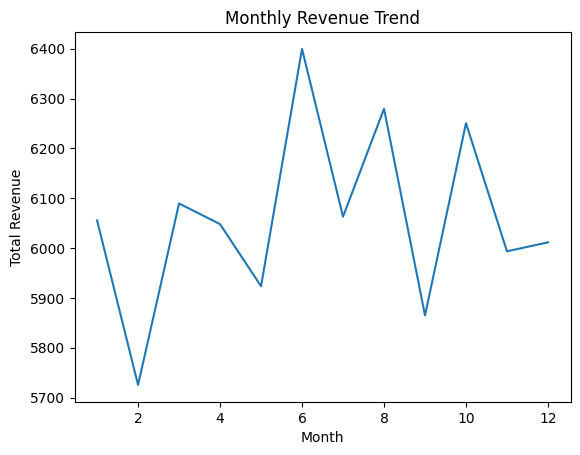

In [203]:
#Revenue trend by month (Line chart)
plt.plot(sales_month)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month') # Added x-axis label
plt.ylabel('Total Revenue') # Added y-axis label
plt.show()

###Why this chart?
 A line chart is ideal for visualizing trends over time. In this case, it helps us understand the monthly sales performance and identify any seasonal patterns or growth.
###Insights:
 The line chart shows the overall monthly revenue trend. We can observe fluctuations throughout the year, with some months performing better than others. For example, June and August appear to have slightly higher revenues.

In [204]:
#Which payment method is most used?
payment_method = df['payment method'].value_counts()

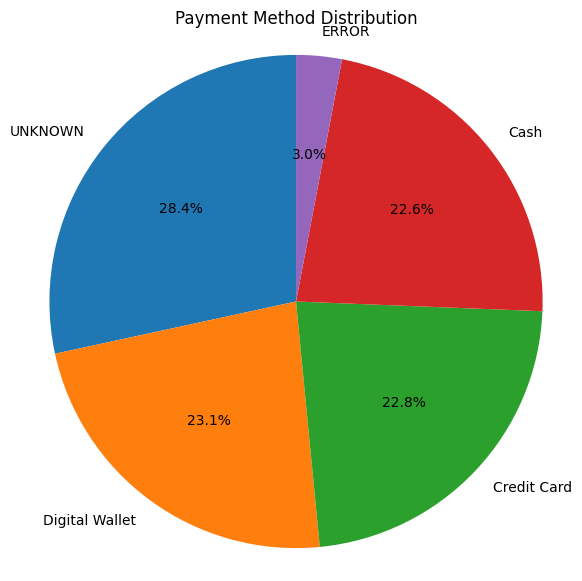

In [226]:
#Payment method distribution (Pie chart)
plt.figure(figsize=(7,7))
plt.pie(payment_method, autopct='%1.1f%%', labels=payment_method.index, startangle=90)
plt.title('Payment Method Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

###Why this chart?
 A pie chart is effective for showing the proportion of different categories within a whole. Here, it clearly illustrates the distribution of payment methods used by customers.
###Insights:
The pie chart clearly shows that 'UNKNOWN' is the most frequent payment method (due to missing value imputation), followed closely by 'Digital Wallet', 'Credit Card', and 'Cash'. This indicates a diverse range of payment preferences, with digital options being very popular.

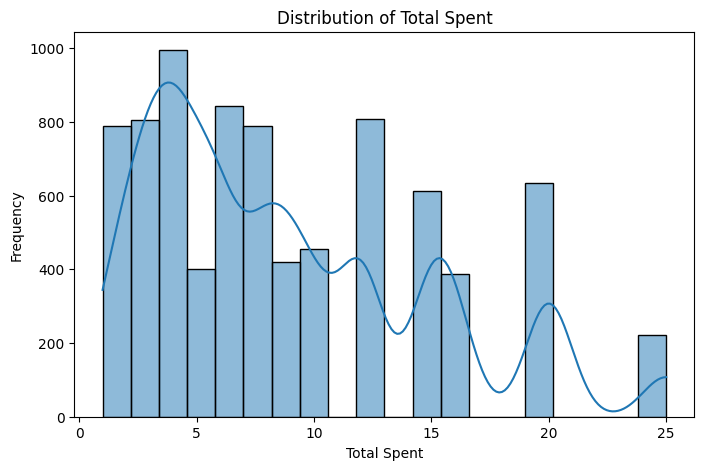

In [220]:
# Distribution of total_spent (Histogram)
plt.figure(figsize=(8,5))
sns.histplot(df['total spent'], bins=20, kde=True)
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

###Why this chart?
A histogram is used to display the distribution of a numerical variable. It helps us understand the frequency of different total spent values and identify its shape, central tendency, and spread.
###Insights:
The histogram of 'Total Spent' shows that most transactions involve smaller amounts, with the frequency decreasing as the total spent increases. This suggests a common pattern of many small purchases and fewer large ones.

<Axes: ylabel='total spent'>

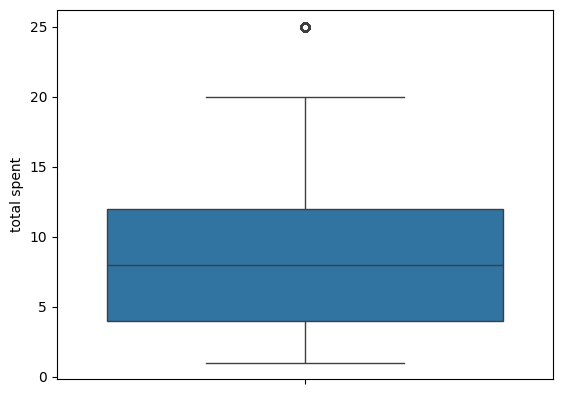

In [223]:
#Boxplot for outliers (total_spent)
sns.boxplot(df['total spent'])

###Why this chart?
A histogram is used to display the distribution of a numerical variable. It helps us understand the frequency of different total spent values and identify its shape, central tendency, and spread.
###Insights:
The histogram of 'Total Spent' shows that most transactions involve smaller amounts, with the frequency decreasing as the total spent increases. This suggests a common pattern of many small purchases and fewer large ones.

In [228]:
pivot = df.pivot_table(values='total spent', index='day', columns='month', aggfunc='sum')

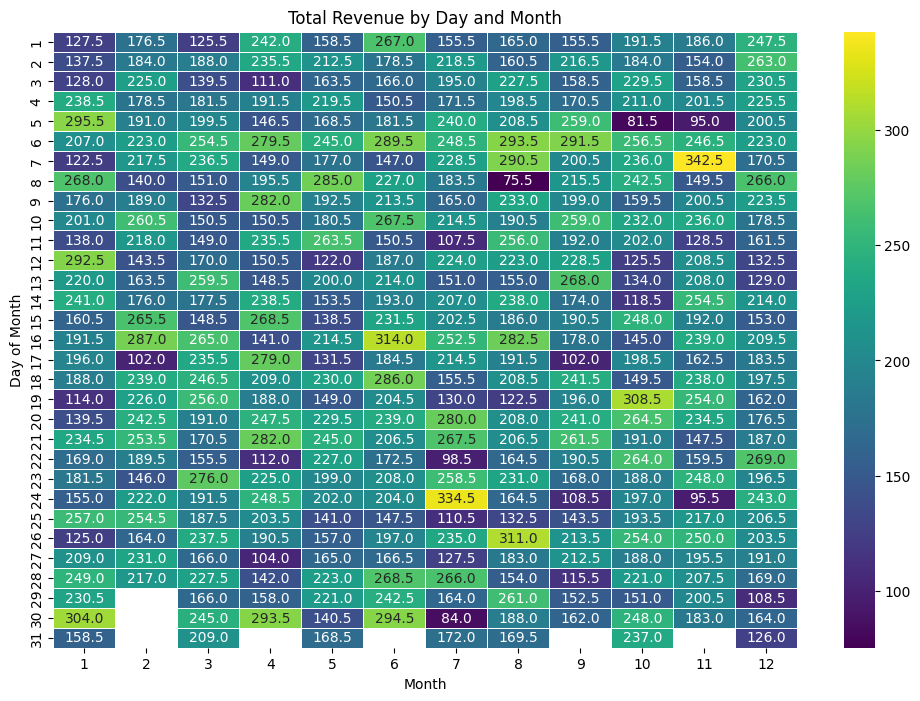

In [229]:
#Heatmap (Day vs Month revenue)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='viridis', annot=True, fmt=".1f", linewidths=.5)
plt.title('Total Revenue by Day and Month')
plt.xlabel('Month')
plt.ylabel('Day of Month')
plt.show()